# Supplement 2 — Robot Joint Torques: clustering in many dimensions

### DBSCAN lecture series · unsupervised learning with scikit-learn

**Companion to the main lecture notebook.** Same algorithm, a harder feature space.

> ### The lesson of this notebook
> Two things bite you once a feature vector gets long. First, **features that carry no
> information still cost you distance** — in standardised space every dead channel adds a
> full unit of variance to every pairwise distance, blurring the geometry DBSCAN depends on.
> Second, and more important: **a fault you have not measured is a fault you cannot find.**
> We give three fault types and three families of feature, and show that each fault is
> visible to exactly one family.

---

### The robotics problem

A 6-axis industrial robot runs a pick-and-place cell, moving parts from an infeed conveyor to
a pallet. Three part variants (A, B and C) are handled by three programs that differ mainly in
**payload**: 1.5 kg, 5.0 kg and 9.0 kg. The controller logs commanded joint torque for all six
axes at 100 Hz. Nobody labels the cycles.

Three things go wrong over a production week:

| fault | what physically happens |
|---|---|
| **collision** | the tool clips a fixture — a short, violent torque transient, mostly on J2/J3 |
| **J5 belt wear** | a drive belt loses tension; friction torque on J5 climbs and stays high |
| **dropped part** | the gripper loses the part mid-transfer — the payload torque vanishes partway through the cycle |

Notice they have completely different *shapes* in time: an impulse, a level shift, and a step
partway through. Remember that when we choose features.

### Learning objectives

- summarise a **time series per cycle** into a feature vector, and see why the summary
  statistic you choose determines which faults survive it;
- measure how much information each feature actually carries, with a
  **between-group / within-group variance ratio**;
- understand why `MinPts ≥ 2d` becomes useless advice at $d = 18$, and what to use instead;
- use **PCA** to sharpen a k-distance knee, and know what PCA does *not* guarantee;
- run a fair **feature-ablation study** at a fixed alarm budget.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans, HDBSCAN
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             precision_score, recall_score)

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3,
                     "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = ["#2563eb", "#f59e0b", "#10b981", "#8b5cf6", "#0891b2", "#ec4899"]
NOISE_C = "#dc2626"
RANDOM_STATE = 23

import sklearn
print("scikit-learn", sklearn.__version__)

scikit-learn 1.8.0


In [2]:
def k_distance(X, k):
    """Sorted distance from each point to its k-th nearest neighbour."""
    d, _ = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(X)
    return np.sort(d[:, -1])


def plot_k_distance(X, k, eps=None, ax=None, title=None):
    kd = k_distance(X, k)
    ax = ax or plt.subplots(figsize=(7.5, 4.2))[1]
    ax.plot(kd, lw=2.2, color="#2563eb")
    if eps is not None:
        ax.axhline(eps, color=NOISE_C, ls="--", lw=1.6)
        ax.text(0.02 * len(kd), eps * 1.06, f"chosen eps = {eps}", color=NOISE_C, fontweight="bold")
    ax.set_xlabel("points sorted by k-distance")
    ax.set_ylabel(f"{k}-NN distance (standardised units)")
    ax.set_title(title or f"Sorted {k}-distance plot", fontweight="bold")
    return ax


def cluster_report(X, labels, truth=None, healthy_mask=None):
    """Standard summary: cluster count, noise rate, silhouette, and -- when ground
    truth is available -- regime ARI plus anomaly precision/recall."""
    m = labels != -1
    out = {"n_clusters": len(set(labels) - {-1}),
           "n_noise": int((~m).sum()),
           "noise_pct": round(100 * (~m).mean(), 1)}
    if len(set(labels[m])) > 1:
        out["silhouette"] = round(silhouette_score(X[m], labels[m]), 3)
    if truth is not None and healthy_mask is not None:
        h = healthy_mask
        if (h & m).sum() and len(set(labels[h & m])) > 1:
            out["ARI_regimes"] = round(adjusted_rand_score(truth[h & m], labels[h & m]), 3)
        out["anomaly_precision"] = round(precision_score(~h, ~m, zero_division=0), 3)
        out["anomaly_recall"] = round(recall_score(~h, ~m, zero_division=0), 3)
    return out


def scatter_labels(ax, XY, labels, title="", s=20, legend=True, names=None):
    for k in sorted(set(labels) - {-1}):
        sel = labels == k
        lbl = (names or {}).get(k, f"cluster {k}")
        ax.scatter(*XY[sel].T, s=s, c=PALETTE[k % len(PALETTE)], ec="none", alpha=.85,
                   label=f"{lbl}  (n={sel.sum()})")
    sel = labels == -1
    if sel.any():
        ax.scatter(*XY[sel].T, s=s * 4, c=NOISE_C, marker="X", ec="white", lw=.7, zorder=5,
                   label=f"noise, label = -1  (n={sel.sum()})")
    ax.set_title(title, fontweight="bold")
    if legend:
        ax.legend(fontsize=9)
    return ax

---
# 1. Simulating the cell

A rigid-body model is enough to produce realistic torque traces. For each joint $i$,

$$\tau_i(t) \;=\; \underbrace{J_i\,\ddot{q}_i(t)}_{\text{inertial}} \;+\; \underbrace{g_i\,m_{\text{payload}}(t)}_{\text{gravity}} \;+\; \underbrace{f_i\,\operatorname{sign}\dot{q}_i(t)}_{\text{friction}} \;+\; \varepsilon$$

The cycle uses a trapezoidal velocity profile: accelerate, cruise, decelerate. The **payload is
carried only in the second half** of the cycle — the robot reaches out empty, grips, and
transfers. That detail matters, because it means the payload signature lives in the second
half of the trace and nowhere else.

Joints 2, 3 and 5 carry the gravity load. **Joints 1, 4 and 6 do not** — J1 is the base
rotation about a vertical axis, and J4/J6 are wrist rolls. Keep that in mind; it comes back
in §3.

In [3]:
NT = 240                                    # samples per cycle (2.4 s at 100 Hz)
JOINTS = [f"J{i}" for i in range(1, 7)]

INERTIA = np.array([9.0, 14.0, 6.5, 1.8, 1.2, 0.5])     # effective inertia [kg m^2]
GRAV    = np.array([0.0, 2.30, 1.15, 0.0, 0.22, 0.0])   # holding torque [N m per kg of payload]
FRIC    = np.array([3.2, 4.0, 2.4, 1.1, 0.9, 0.6])      # Coulomb friction [N m]


def run_cycle(rng, payload_kg, fric_scale=None, collision=False, dropped=False):
    """Simulate one pick-and-place cycle. Returns a (NT, 6) array of joint torques [N m]."""
    acc = np.zeros(NT)                                   # trapezoidal velocity profile
    acc[:NT // 4] = 1.0
    acc[NT // 2:3 * NT // 4] = -1.0
    acc = np.convolve(acc, np.ones(9) / 9, mode="same")  # smooth the jerk
    vel = np.cumsum(acc) / NT * 4.0

    scale = np.array([1.0, 0.85, 0.7, 0.5, 0.45, 0.3]) * rng.normal(1.0, 0.012, 6)
    fric = FRIC * (1.0 if fric_scale is None else fric_scale)

    carried = np.full(NT, payload_kg)                    # payload only during the transfer
    carried[:NT // 2] = 0.0
    if dropped:
        carried[3 * NT // 5:] = 0.0                      # the part slips out mid-transfer

    tau = ((INERTIA * scale) * acc[:, None]
           + GRAV * carried[:, None]
           + fric * np.tanh(vel[:, None] * 8)
           + rng.normal(0, 0.35, (NT, 6)))

    if collision:
        i0 = rng.integers(int(NT * 0.35), int(NT * 0.75))
        pulse = np.zeros(NT)
        pulse[i0:i0 + 7] = np.hanning(7) * rng.uniform(28, 48)
        felt = np.array([0.35, 1.0, 0.85, 0.25, 0.15, 0.05])   # transmitted mostly to J2/J3
        tau += pulse[:, None] * felt

    return tau

## 1.1 What each condition looks like in time

Plot J2 (the shoulder — it carries the payload and feels a collision) and J5 (the wrist pitch
— where the belt wears) for a normal cycle and for each fault.

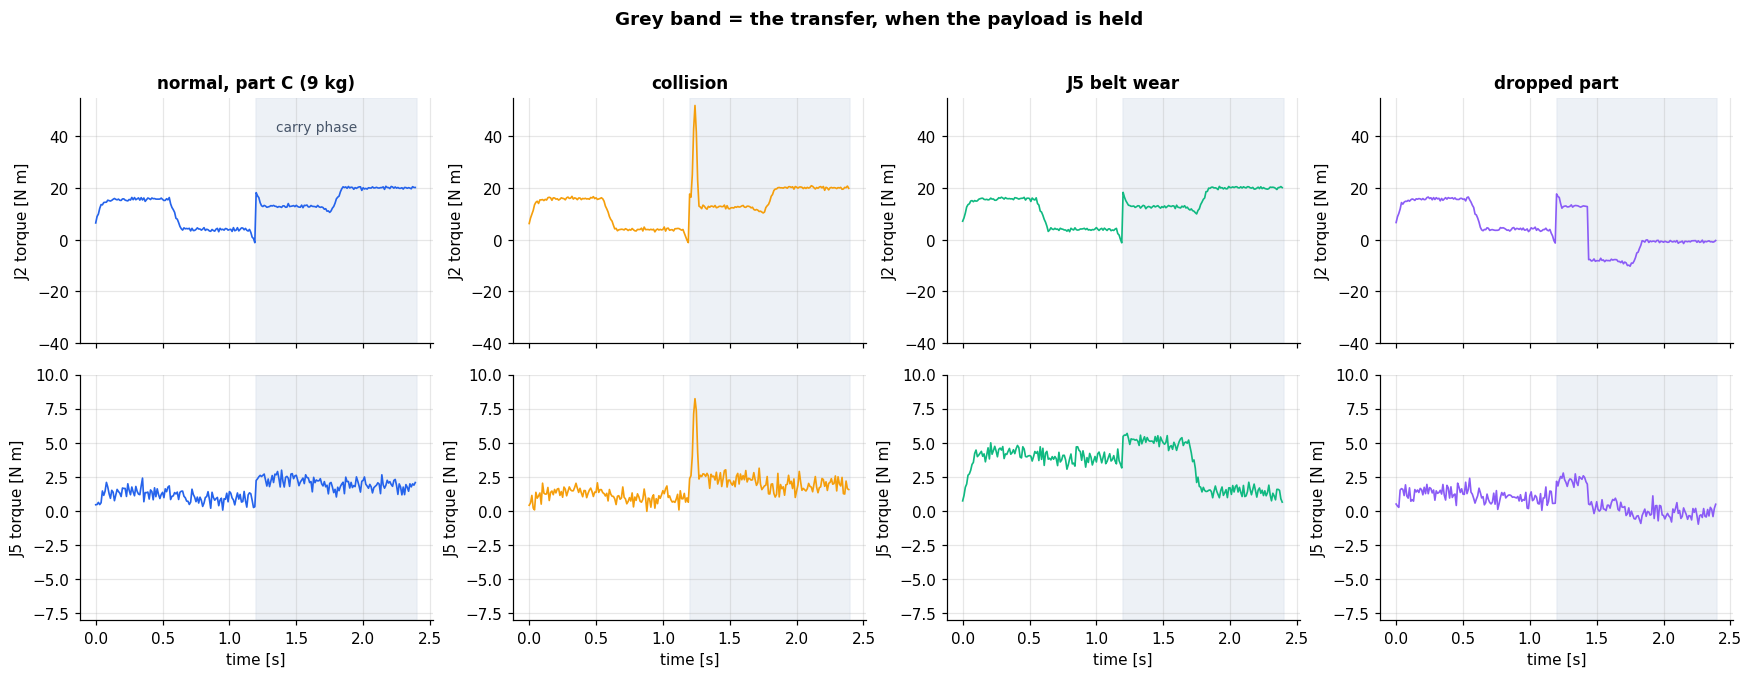

In [4]:
rng_demo = np.random.default_rng(5)
belt = np.ones(6); belt[4] = 4.2; belt[3] = 1.6
demos = [("normal, part C (9 kg)", run_cycle(rng_demo, 9.0)),
         ("collision",             run_cycle(rng_demo, 9.0, collision=True)),
         ("J5 belt wear",          run_cycle(rng_demo, 9.0, fric_scale=belt)),
         ("dropped part",          run_cycle(rng_demo, 9.0, dropped=True))]

t = np.arange(NT) / 100.0
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True)
for j, (name, tau) in enumerate(demos):
    for row, joint in [(0, 1), (1, 4)]:                 # J2 and J5 (zero-indexed 1 and 4)
        ax = axes[row, j]
        ax.axvspan(1.2, 2.4, color="#e2e8f0", alpha=.6, zorder=0)
        ax.plot(t, tau[:, joint], lw=1.1, color=PALETTE[j])
        ax.set_ylabel(f"J{joint+1} torque [N m]")
        ax.set_ylim(-40, 55) if row == 0 else ax.set_ylim(-8, 10)
        if row == 1: ax.set_xlabel("time [s]")
    axes[0, j].set_title(name, fontweight="bold", fontsize=11)
axes[0, 0].text(1.35, 42, "carry phase", fontsize=9, color="#475569")
fig.suptitle("Grey band = the transfer, when the payload is held", y=1.02, fontweight="bold")
fig.tight_layout(); plt.show()

Study the four columns — each fault has a different **shape**:

- **collision** — a single narrow spike on J2. The *average* torque over the cycle barely
  moves; only the maximum does.
- **J5 belt wear** — the J5 trace sits well above normal through most of the cycle. The
  average moves a lot; the maximum barely.
- **dropped part** — J2 looks like a normal part-C cycle until 1.44 s, then falls to the
  unloaded level for the rest of the transfer. Neither
  the average nor the maximum is remarkable; what changed is the **variability within the
  carry phase**.

Three faults, three different statistics. That is the design brief for the feature set.

---
# 2. Feature extraction: three families

For each of the six joints we compute three numbers, giving $6 \times 3 = 18$ features:

| family | definition | designed to see |
|---|---|---|
| `*_carry_mean` | mean $\lvert\tau\rvert$ during the transfer phase | payload level, friction — **belt wear** |
| `*_peak` | max $\lvert\tau\rvert$ over the whole cycle | impacts — **collisions** |
| `*_carry_std` | std of $\lvert\tau\rvert$ during the transfer phase | changes *within* the carry — **dropped parts** |

We will test in §5 whether that design brief was actually met.

In [5]:
def extract_features(tau):
    """Three summary statistics per joint -> an 18-dimensional feature vector."""
    carry = slice(NT // 2, None)
    f = {}
    for j, name in enumerate(JOINTS):
        c = np.abs(tau[carry, j])
        f[f"{name}_carry_mean"] = float(c.mean())
        f[f"{name}_peak"] = float(np.max(np.abs(tau[:, j])))
        f[f"{name}_carry_std"] = float(c.std())
    return f

CARRY_MEAN = [f"{j}_carry_mean" for j in JOINTS]
PEAK       = [f"{j}_peak" for j in JOINTS]
CARRY_STD  = [f"{j}_carry_std" for j in JOINTS]
FEATURES   = CARRY_MEAN + PEAK + CARRY_STD
print(len(FEATURES), "features")

18 features


In [6]:
def make_week(seed=RANDOM_STATE):
    """One production week: 460 healthy cycles across three programs, plus 42 faults."""
    rng = np.random.default_rng(seed)
    rows, truth = [], []

    for name, kg, k in [("part_A_light", 1.5, 150),
                        ("part_B_medium", 5.0, 170),
                        ("part_C_heavy", 9.0, 140)]:
        for _ in range(k):
            rows.append(extract_features(run_cycle(rng, kg + rng.normal(0, 0.18))))
            truth.append(name)

    for _ in range(14):                                          # collisions
        kg = [1.5, 5.0, 9.0][rng.integers(3)]
        rows.append(extract_features(run_cycle(rng, kg, collision=True)))
        truth.append("collision")

    for _ in range(16):                                          # J5 belt wear
        kg = [1.5, 5.0, 9.0][rng.integers(3)]
        fs = np.ones(6); fs[4] = rng.uniform(3.4, 5.0); fs[3] = rng.uniform(1.3, 1.9)
        rows.append(extract_features(run_cycle(rng, kg, fric_scale=fs)))
        truth.append("j5_belt_wear")

    for _ in range(12):                                          # dropped parts
        rows.append(extract_features(run_cycle(rng, 9.0 + rng.normal(0, 0.18), dropped=True)))
        truth.append("dropped_part")

    df = pd.DataFrame(rows)
    df["true_state"] = truth                                     # for SCORING ONLY
    return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

df = make_week()
healthy = df.true_state.str.startswith("part_").values
print(df.shape)
df.true_state.value_counts()

(502, 19)


true_state
part_B_medium    170
part_A_light     150
part_C_heavy     140
j5_belt_wear      16
collision         14
dropped_part      12
Name: count, dtype: int64

In [7]:
df.groupby("true_state")[["J2_carry_mean", "J2_peak", "J2_carry_std",
                          "J5_carry_mean", "J5_carry_std"]].mean().round(2)

,J2_carry_mean,J2_peak,J2_carry_std,J5_carry_mean,J5_carry_std
true_state,,,,,
collision,9.49,42.25,4.24,1.28,0.74
dropped_part,5.58,18.38,5.24,0.74,0.86
j5_belt_wear,6.92,17.21,2.78,2.17,1.73
part_A_light,3.62,16.63,1.23,0.48,0.34
part_B_medium,7.23,16.62,3.70,1.18,0.43
part_C_heavy,16.32,20.87,3.71,2.05,0.43


The table already tells the story that §5 will make rigorous:

- **collision** stands out only in `J2_peak` — 42.3, against 16.6–20.9 for every other state;
- **j5_belt_wear** shows up in the J5 columns, and most sharply in `J5_carry_std` (1.73
  against 0.34–0.86 elsewhere); in `J5_carry_mean` it is 2.17 against part C's 2.05, which on
  its own would be far too close to call;
- **dropped_part** has an unremarkable `J2_carry_mean` of 5.6 — right between part A (3.6) and
  part B (7.2) — and an unremarkable peak. Its signature is `J2_carry_std`.

---
# 3. How much of this is actually information?

Eighteen features sounds thorough. Let us check how many of them carry any signal at all.

A cheap and very effective diagnostic: for each feature, compute the **variance of the
program means divided by the mean within-program variance**. Big means the feature separates
the three programs; near zero means it is the same everywhere and contributes only noise.
(This is the one-way ANOVA F-statistic in spirit.)

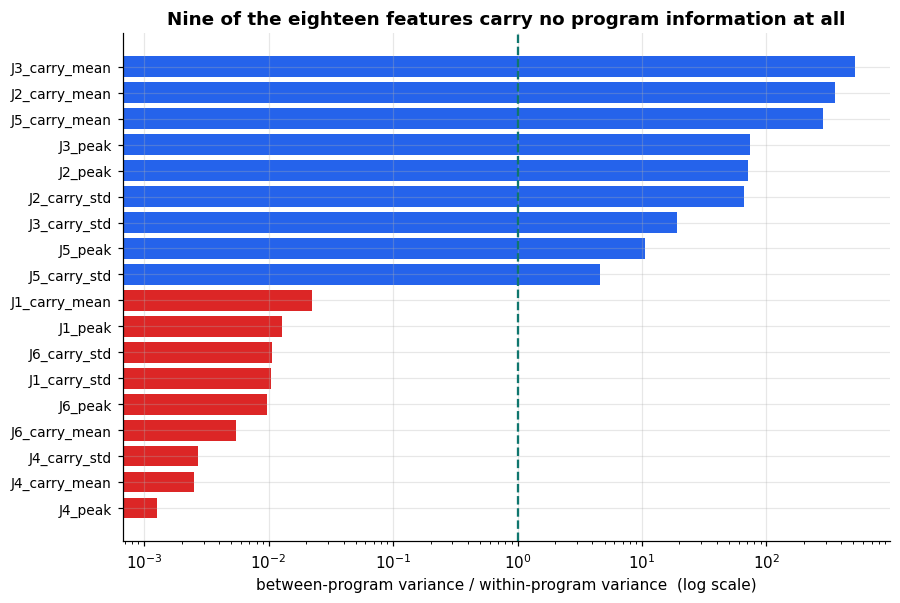

features with ratio < 0.1 : 9 of 18
J3_carry_mean    514.20
J2_carry_mean    355.56
J5_carry_mean    284.68
J3_peak           73.46
J2_peak           70.60
J2_carry_std      66.27
J3_carry_std      19.13
J5_peak           10.63
J5_carry_std       4.61
J1_carry_mean      0.02
J1_peak            0.01
J6_carry_std       0.01
J1_carry_std       0.01
J6_peak            0.01
J6_carry_mean      0.00
J4_carry_std       0.00
J4_carry_mean      0.00
J4_peak            0.00


In [8]:
h = df[healthy]
info = {}
for f in FEATURES:
    g = h.groupby("true_state")[f]
    info[f] = g.mean().var() / max(g.var().mean(), 1e-12)
info = pd.Series(info).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2563eb" if v > 1 else NOISE_C for v in info.values]
ax.barh(range(len(info)), info.values + 1e-3, color=colors)
ax.set_yticks(range(len(info))); ax.set_yticklabels(info.index, fontsize=9)
ax.set_xscale("log"); ax.invert_yaxis()
ax.axvline(1.0, color="#0f766e", ls="--", lw=1.5)
ax.set_xlabel("between-program variance / within-program variance  (log scale)")
ax.set_title("Nine of the eighteen features carry no program information at all",
             fontweight="bold")
plt.show()

print(f"features with ratio < 0.1 : {(info < 0.1).sum()} of {len(info)}")
print(info.round(2).to_string())

Exactly the nine features belonging to **J1, J4 and J6** score essentially zero — and that is
not an accident of the simulation, it is the kinematics. Those axes do not work against
gravity, so the payload never appears in their torque, and all three programs look identical
through them.

**Why this costs you.** After `StandardScaler`, every feature has variance 1. A squared
Euclidean distance is a sum over features, so those nine dead channels contribute roughly
nine units of pure noise to *every* pairwise distance, while the nine informative ones carry
the signal. The structure is still there, but it is sitting on a noise floor — and that shows
up directly in the k-distance plot as a blurred knee.

## 3.1 MinPts, and why `2d` stops helping

The main lecture's rule of thumb was MinPts $\ge 2d$. At $d = 18$ that prescribes 36, which
would be a quarter of the smallest program cluster and would dissolve every fault group.

The rule was always about the **intrinsic** dimension — the number of directions the data
actually varies in — not the number of columns in your dataframe. Here the intrinsic
dimension is far below 18, and PCA is the easiest way to see it. We keep **MinPts = 12**.

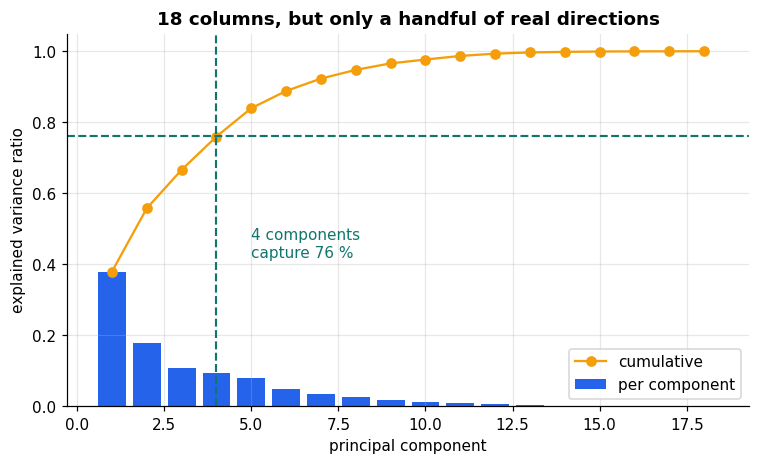

cumulative explained variance: [0.379 0.558 0.666 0.76  0.84  0.888]


In [9]:
X = StandardScaler().fit_transform(df[FEATURES].values)
pca = PCA(random_state=RANDOM_STATE).fit(X)
cum = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.bar(range(1, 19), pca.explained_variance_ratio_, color="#2563eb", label="per component")
ax.plot(range(1, 19), cum, "o-", color="#f59e0b", label="cumulative")
ax.axhline(0.76, color="#0f766e", ls="--", lw=1.4)
ax.axvline(4.0, color="#0f766e", ls="--", lw=1.4)
ax.text(5.0, 0.42, "4 components\ncapture 76 %", color="#0f766e", fontsize=10)
ax.set_xlabel("principal component"); ax.set_ylabel("explained variance ratio")
ax.set_title("18 columns, but only a handful of real directions", fontweight="bold")
ax.legend(); plt.show()

print("cumulative explained variance:", cum[:6].round(3))

---
# 4. Clustering, before and after PCA

Now the comparison that matters. Run the identical DBSCAN in both spaces and judge them on
the same terms: can they recover the three programs, and at what false-alarm cost?

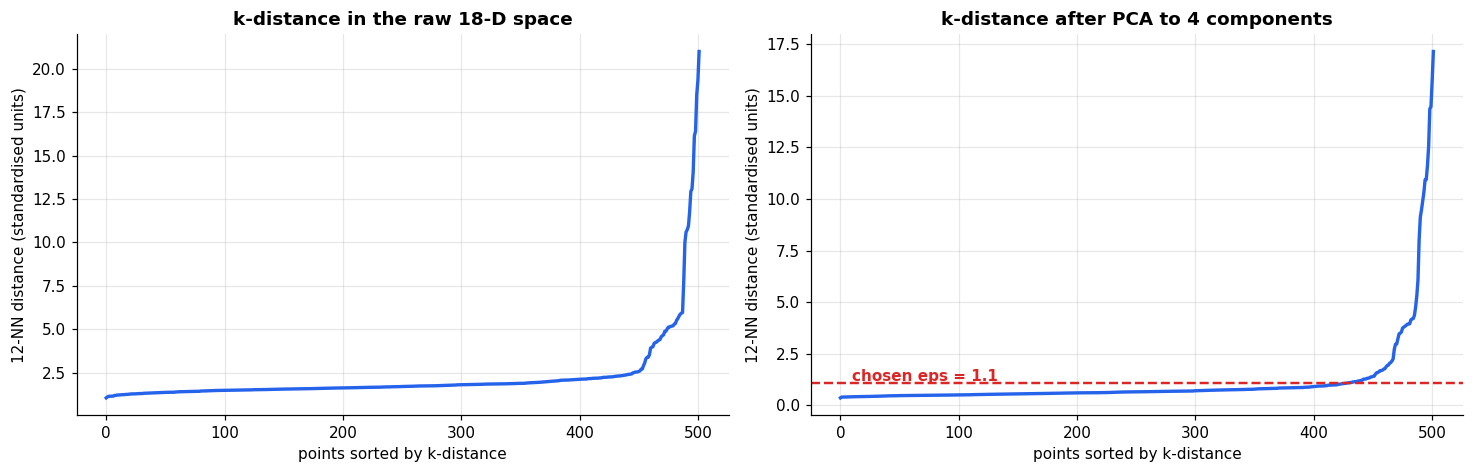

raw 18-D   k-distance percentiles {50: 1.71, 80: 2.13, 88: 2.4, 92: 3.96, 95: 5.13}
PCA 4-D    k-distance percentiles {50: 0.66, 80: 0.92, 88: 1.23, 92: 1.86, 95: 3.79}


In [10]:
MIN_SAMPLES = 12
Z4 = PCA(n_components=4, random_state=RANDOM_STATE).fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
plot_k_distance(X, MIN_SAMPLES, ax=axes[0], title="k-distance in the raw 18-D space")
plot_k_distance(Z4, MIN_SAMPLES, eps=1.1, ax=axes[1], title="k-distance after PCA to 4 components")
fig.tight_layout(); plt.show()

for tag, M in [("raw 18-D", X), ("PCA 4-D", Z4)]:
    kd = k_distance(M, MIN_SAMPLES)
    pct = {p: round(float(np.percentile(kd, p)), 2) for p in (50, 80, 88, 92, 95)}
    print(f"{tag:10s} k-distance percentiles {pct}")

The left curve rises gradually with no obvious corner; the right one is flat and then turns
sharply. That difference *is* the nine dead dimensions being removed.

In [11]:
rows = []
for tag, M, eps_grid in [("raw 18-D", X, [1.5, 1.8, 2.1, 2.4]),
                         ("PCA 4-D", Z4, [0.7, 0.9, 1.1, 1.3])]:
    for eps in eps_grid:
        lb = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(M)
        rows.append({"space": tag, "eps": eps,
                     **cluster_report(M, lb, truth=df.true_state.values, healthy_mask=healthy)})
pd.DataFrame(rows).set_index(["space", "eps"])

n_clusters  n_noise  noise_pct  silhouette  ARI_regimes  \
space    eps                                                            
raw 18-D 1.5           4      186       37.1       0.306        0.975   
         1.8           3       70       13.9       0.311        1.000   
         2.1           3       50       10.0       0.301        1.000   
         2.4           2       45        9.0       0.337        0.542   
PCA 4-D  0.7           3       92       18.3       0.498        1.000   
         0.9           3       54       10.8       0.459        1.000   
         1.1           3       47        9.4       0.451        1.000   
         1.3           3       43        8.6       0.446        1.000   

              anomaly_precision  anomaly_recall  
space    eps                                     
raw 18-D 1.5              0.226           1.000  
         1.8              0.600           1.000  
         2.1              0.840           1.000  
         2.4              0.933           1.000  
PCA 4-D  0.7              0.457           1.000  
         0.9              0.778           1.000  
         1.1              0.894           1.000  
         1.3              0.930           0.952

Both spaces can recover the three programs — the raw 18-D space is **not** unusable, and it
would be dishonest to claim otherwise. What the dead dimensions cost you is precision at
equal recall, and the ease of picking ε:

- the best raw 18-D setting that still recovers all three programs is ε ≈ 2.1, giving
  **0.84 precision** at recall 1.00 (push ε to 2.4 and precision rises, but two programs
  merge — ARI drops to 0.54, so that setting is no longer solving the problem);
- PCA 4-D reaches **0.89 precision** at recall 1.00, with a knee you can actually see.

In a cell running thousands of cycles a week, that difference is real money in unnecessary
stoppages. And the diagnosis — *nine of my features are dead* — is worth far more than the
few points of precision: it tells you to instrument something else, or to stop logging J1,
J4 and J6 entirely.

> **A caveat on PCA.** PCA keeps the directions of greatest *variance*, which is not the same
> as the directions of greatest *cluster separation*. It helped here because the informative
> features happened also to be the high-variance ones. It can just as easily discard a
> low-variance direction that was the only thing separating two clusters. Always check the
> result, as we do below, rather than trusting the projection.

In [12]:
EPS = 1.1
labels = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit_predict(Z4)

report = cluster_report(Z4, labels, truth=df.true_state.values, healthy_mask=healthy)
for k, v in report.items():
    print(f"{k:>18s} : {v}")
print()
print(pd.crosstab(pd.Series(df.true_state.values, name="true_state"),
                  pd.Series(labels, name="dbscan_label")))

        n_clusters : 3
           n_noise : 47
         noise_pct : 9.4
        silhouette : 0.451
       ARI_regimes : 1.0
 anomaly_precision : 0.894
    anomaly_recall : 1.0

dbscan_label   -1    0    1    2
true_state                      
collision      14    0    0    0
dropped_part   12    0    0    0
j5_belt_wear   16    0    0    0
part_A_light    2  148    0    0
part_B_medium   3    0  167    0
part_C_heavy    0    0    0  140


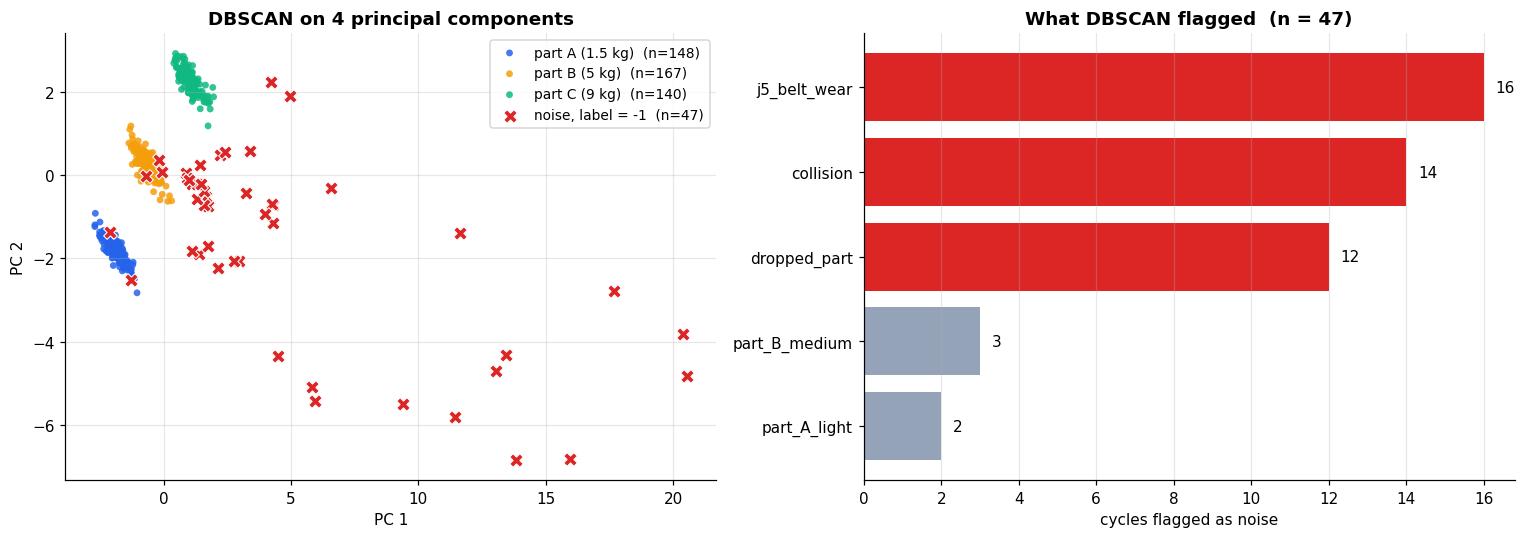

In [13]:
means = pd.Series(df.J2_carry_mean.values).groupby(labels).mean().drop(index=-1, errors="ignore")
names = {k: nm for k, nm in zip(means.sort_values().index,
                                ["part A (1.5 kg)", "part B (5 kg)", "part C (9 kg)"])}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter_labels(axes[0], Z4[:, :2], labels, "DBSCAN on 4 principal components", names=names)
axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")

flagged = df[labels == -1].true_state.value_counts()
axes[1].barh(flagged.index[::-1], flagged.values[::-1],
             color=[("#94a3b8" if s.startswith("part_") else NOISE_C) for s in flagged.index[::-1]])
for i, v in enumerate(flagged.values[::-1]):
    axes[1].text(v + 0.3, i, str(v), va="center", fontsize=10)
axes[1].set_title(f"What DBSCAN flagged  (n = {int((labels == -1).sum())})", fontweight="bold")
axes[1].set_xlabel("cycles flagged as noise"); axes[1].grid(axis="y")
fig.tight_layout(); plt.show()

All 42 faults caught, and the three programs recovered exactly. Note that the fault cycles do
**not** form clusters of their own here — 14 collisions scattered across three payloads are
too sparse to reach MinPts, so they stay noise. Contrast that with the wind-turbine
supplement, where a repeating fault *does* become its own cluster.

---
# 5. Does each fault need its own feature family?

This is the experiment the notebook exists for. We re-run the same pipeline on subsets of the
feature families, tuning ε in each case so that roughly the **same number of cycles is
flagged** — otherwise a subset could look good simply by alarming more often.

In [14]:
def ablate(feats, budget=47, min_samples=12, n_components=4):
    """Cluster on `feats`, tuning eps to flag about `budget` cycles, then report
    which fault types were actually caught."""
    Xs = StandardScaler().fit_transform(df[feats].values)
    Zs = PCA(n_components=min(n_components, Xs.shape[1]),
             random_state=RANDOM_STATE).fit_transform(Xs)
    best = None
    for eps in np.arange(0.20, 3.0, 0.01):
        lb = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(Zs)
        nz = int((lb == -1).sum())
        if best is None or abs(nz - budget) < abs(best[1] - budget):
            best = (eps, nz, lb)
    eps, nz, lb = best
    out = {"n_features": len(feats), "eps": round(eps, 2), "alarms": nz,
           "programs_found": len(set(lb) - {-1})}
    for fault in ["collision", "j5_belt_wear", "dropped_part"]:
        out[fault] = round(float((lb == -1)[df.true_state.values == fault].mean()), 2)
    return out

subsets = {
    "all three families": FEATURES,
    "carry_mean + peak (no std)": CARRY_MEAN + PEAK,
    "carry_mean + std (no peak)": CARRY_MEAN + CARRY_STD,
    "peak + std (no carry_mean)": PEAK + CARRY_STD,
    "carry_mean only": CARRY_MEAN,
}
pd.DataFrame([{"feature set": k, **ablate(v)} for k, v in subsets.items()]).set_index("feature set")

,n_features,eps,alarms,programs_found,collision,j5_belt_wear,dropped_part
feature set,,,,,,,
all three families,18,1.09,47,3,1.00,1.0,1.00
carry_mean + peak (no std),12,0.86,48,3,1.00,1.0,0.25
carry_mean + std (no peak),12,1.12,47,3,0.64,1.0,1.00
peak + std (no carry_mean),12,0.89,48,1,1.00,1.0,1.00
carry_mean only,6,0.95,48,2,0.64,1.0,0.42


Read the three fault columns. The pattern is the point of the notebook:

- **Remove `carry_std`** and dropped parts fall from 1.00 to **0.25**. A torque level between
  "part B" and "part C" is an entirely plausible payload, so with only means and peaks nothing
  in the feature set finds it strange.
- **Remove `peak`** and collision recall falls from 1.00 to **0.64** — a seven-sample spike
  barely moves a 120-sample mean, so a third of the collisions slip through.
- **`carry_mean` alone** finds only two of the three programs, and catches belt wear perfectly
  (that fault *is* a shift in mean) but only 0.64 of collisions and 0.42 of dropped parts.
- **Remove `carry_mean`** and something different happens: all three faults are still caught,
  but only **one** program is found. Payload level is precisely what distinguishes the
  programs, so without it the three merge into a single cluster. Detection survives;
  *baselining* does not.

That last row is worth pausing on. A feature set can be good for anomaly detection and useless
for describing normal operation, or the reverse. Decide which job you are doing.

> **The practical rule.** Before you cluster, list the failure modes you care about and ask,
> for each one, *which number in my feature vector changes when this happens?* If you cannot
> answer for a failure mode, no unsupervised method will find it — you have not measured it.

---
# 6. Two practical notes

## 6.1 What counts as a "point"?

We clustered **one point per cycle**. The alternative — one point per 10 ms sample — answers a
different question: it would find *motion primitives* (accelerating, cruising, holding) rather
than *cycle types*, and a collision would be a handful of odd samples rather than an odd cycle.

Neither framing is more correct. Choose it from the decision you need to make: cycle-level for
"should this part be inspected?", sample-level for "what was the robot doing at 14:32:07?".

## 6.2 Changing the metric changes what ε means

For long feature vectors people often reach for `metric="cosine"`. The instinct behind it is
that only the *pattern* should matter, not the overall magnitude. Here magnitude looks like it
**is** the signal — a 9 kg payload differs from a 1.5 kg one in scale — so you might expect
cosine to damage the program structure. Let us check rather than assume — and let us look at
more than one number when we do.

In [15]:
rows = []
for metric, eps_grid in [("euclidean", [1.5, 1.8, 2.1, 2.4]),
                         ("cosine",    [0.05, 0.10, 0.20, 0.30])]:
    for eps in eps_grid:
        lb = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, metric=metric).fit_predict(X)
        m = lb != -1
        ari = (adjusted_rand_score(df.true_state[healthy & m], lb[healthy & m])
               if (healthy & m).sum() and len(set(lb[healthy & m])) > 1 else np.nan)
        rows.append({"metric": metric, "eps": eps, "clusters": len(set(lb) - {-1}),
                     "noise": int((~m).sum()), "ARI_programs": round(ari, 3)})
display(pd.DataFrame(rows).set_index(["metric", "eps"]))

# the summary numbers look fine for cosine -- so look at the actual assignment
lb_cos = DBSCAN(eps=0.20, min_samples=MIN_SAMPLES, metric="cosine").fit_predict(X)
print("\ncosine, eps = 0.20:")
print(pd.crosstab(pd.Series(df.true_state.values, name="true_state"),
                  pd.Series(lb_cos, name="cosine_label")))

clusters  noise  ARI_programs
metric    eps                                
euclidean 1.50         4    186         0.975
          1.80         3     70         1.000
          2.10         3     50         1.000
          2.40         2     45         0.542
cosine    0.05         0    502           NaN
          0.10         5    309         0.739
          0.20         4     98         1.000
          0.30         3     14           NaN


cosine, eps = 0.20:
cosine_label   -1    0   1    2   3
true_state                         
collision      14    0   0    0   0
dropped_part   12    0   0    0   0
j5_belt_wear    0    0   0    0  16
part_A_light    0  150   0    0   0
part_B_medium  72    0  98    0   0
part_C_heavy    0    0   0  140   0


Look at the summary table first: cosine at ε = 0.20 reports **ARI 1.000** on the programs.
It looks like a success, and if you stopped there you would ship it.

Now look at the crosstab underneath, which is the same run:

- **72 of the 170 part-B cycles are flagged as noise** — a 42 % false-alarm rate on a program
  that is running perfectly;
- **all 16 belt-wear cycles form a cluster of their own**, so they are *not* flagged at all.
  The fault has been quietly promoted to a normal operating mode.

So cosine is not fine here; it is bad in exactly the way the original intuition suggested,
and the summary metric hid it. Two lessons, and the second is the more valuable:

1. **ε does not transfer between metrics.** Euclidean needs ε ≈ 2.1 in this space; cosine
   distance is bounded in [0, 2] no matter how many features you have, and needs ε ≈ 0.2.
   Change the metric, the scaler or the dimension and you must re-derive ε from a fresh
   k-distance plot. There is no good default ε.
2. **A single score can hide a failure.** `ARI_programs` is computed on the healthy,
   *non-noise* points only — so a method that rejects a large slice of a program before
   scoring gets *rewarded* for it. Any conditional metric flatters a method that abstains.
   Always print the crosstab.

---
# 7. Summary

1. **Dead features are not free.** After standardisation, every uninformative channel adds a
   full unit of variance to every distance. Here nine of eighteen features carried no program
   information — a fact of the robot's kinematics, visible in one bar chart.
2. The **between-group / within-group variance ratio** is a two-line diagnostic worth running
   before any clustering.
3. `MinPts ≥ 2d` refers to the **intrinsic** dimension, not the column count. At $d = 18$ take
   the rule as advice to reduce dimension, not to raise MinPts to 36.
4. **PCA sharpened the k-distance knee** and bought precision at equal recall — but PCA
   optimises variance, not separability, so verify rather than assume.
5. **Read the crosstab, not just the score.** Cosine distance reported a perfect ARI here
   while silently false-alarming on 42 % of one program and reclassifying a fault as a normal
   mode. Metrics conditioned on the non-noise points reward a method for abstaining.
6. **The headline: your feature families determine which faults are detectable.** Impulse
   faults need a peak; level faults need a mean; mid-cycle changes need a within-cycle spread.
   A fault with no corresponding feature is invisible to any clustering algorithm.

---
# 8. Exercises

1. **Design a fourth feature family.** Add `*_carry_slope` (the linear trend of $\lvert\tau\rvert$
   through the carry phase). Which fault does it detect best? Does it make `carry_std` redundant?
2. **A fault you cannot see.** Add a **backlash** fault: a small oscillation on J3 at 12 Hz,
   with unchanged mean, peak and standard deviation. Confirm that none of the 18 features
   detects it, then design one that does.
3. **Prune instead of project.** Drop the nine J1/J4/J6 features entirely and cluster on the
   remaining nine, with no PCA. How does it compare to PCA on all 18? Which would you rather
   deploy, and why?
4. **Intrinsic dimension.** Estimate it with the k-distance scaling method, or simply compare
   `n_components` from 2 to 8 in §4. Where does performance peak, and why does it fall again?
5. **New programs.** Add a fourth part variant at 7 kg. Does DBSCAN separate it from the 5 kg
   and 9 kg programs, or merge them? What does that say about ε and the payload spacing?
6. **Per-sample clustering.** Re-frame the problem at one point per time sample (all cycles
   concatenated, features = the six instantaneous torques). What do the clusters mean now?

### References

- Ester, Kriegel, Sander & Xu, *A Density-Based Algorithm for Discovering Clusters…*, KDD-96.
- Schubert, Sander, Ester, Kriegel & Xu, *DBSCAN Revisited, Revisited*, ACM TODS 42(3), 2017.
- Siciliano & Khatib (eds.), *Springer Handbook of Robotics*, 2nd ed. — manipulator dynamics.
- ISO 10218 / ISO/TS 15066 — industrial robot safety, including collision force limits.

Generated by Claude and customized by

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>